# Modelling

This notebook models the dataset.

Steps:
1. Seperate training set and test set.
2. Trained a Random Forest Model.
3. Trained a XGBoost Model.
4. Tuned the decision threshold to 0.4.
5. Findings
    - XGBoost with threshold 0.4 achieved 74% recall on churners vs 49% for Random Forest.
    - Contract type is one of the most imporatant feature deciding if customer churned or not.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Load the cleaned dataset from notebook 2
df = pd.read_csv('../data/churn_cleaned.csv')

print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Data loaded: 7043 rows, 35 columns


In [2]:
# Separate features (X) from what we're predicting (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Features: {X.shape[1]} columns")
print(f"Target: {y.value_counts().to_dict()}")

Features: 34 columns
Target: {0: 5174, 1: 1869}


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")
print(f"\nChurn rate in training set: {y_train.mean():.1%}")
print(f"Churn rate in test set: {y_test.mean():.1%}")


Training set: 5634 rows
Test set: 1409 rows

Churn rate in training set: 26.5%
Churn rate in test set: 26.5%


In [4]:
# Train a Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,      # number of decision trees
    class_weight='balanced', # handles our class imbalance
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [5]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Print the full evaluation report
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

              precision    recall  f1-score   support

      Stayed       0.83      0.89      0.86      1035
     Churned       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



In [6]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    scale_pos_weight=3,    # handles class imbalance, similar to class_weight='balanced'
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print(classification_report(y_test, y_pred_xgb, target_names=['Stayed', 'Churned']))

              precision    recall  f1-score   support

      Stayed       0.87      0.78      0.82      1035
     Churned       0.53      0.66      0.59       374

    accuracy                           0.75      1409
   macro avg       0.70      0.72      0.70      1409
weighted avg       0.78      0.75      0.76      1409



In [7]:
# Get probability scores instead of just 0/1 predictions
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Lower threshold from 0.5 to 0.4
# This means: flag as churner if probability > 40% instead of 50%
threshold = 0.4
y_pred_threshold = (y_pred_proba >= threshold).astype(int)

print(f"Results with threshold = {threshold}:")
print(classification_report(y_test, y_pred_threshold, target_names=['Stayed', 'Churned']))

Results with threshold = 0.4:
              precision    recall  f1-score   support

      Stayed       0.89      0.74      0.80      1035
     Churned       0.50      0.74      0.60       374

    accuracy                           0.74      1409
   macro avg       0.69      0.74      0.70      1409
weighted avg       0.78      0.74      0.75      1409



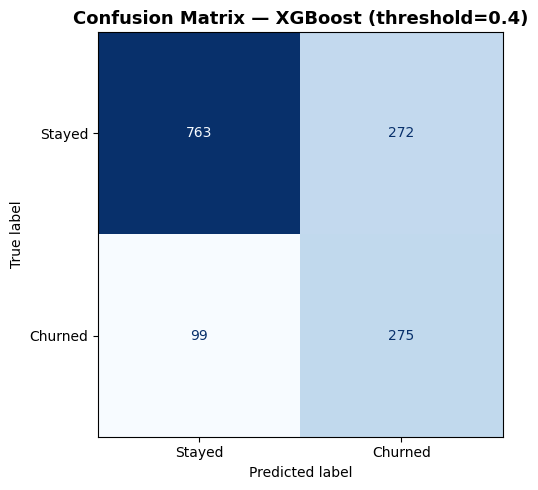

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred_threshold)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Stayed', 'Churned'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

plt.title('Confusion Matrix — XGBoost (threshold=0.4)', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150)
plt.show()

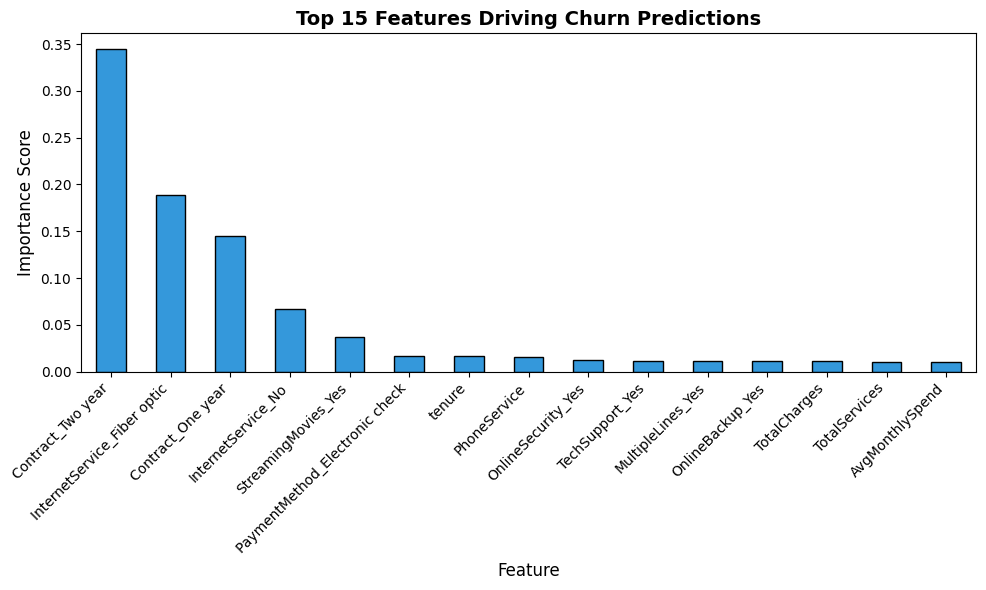


Top 10 most important features:
Contract_Two year                 0.344189
InternetService_Fiber optic       0.188660
Contract_One year                 0.144896
InternetService_No                0.066412
StreamingMovies_Yes               0.036984
PaymentMethod_Electronic check    0.016461
tenure                            0.016455
PhoneService                      0.016091
OnlineSecurity_Yes                0.012073
TechSupport_Yes                   0.011515
dtype: float32


In [9]:
# Feature importance
importance = pd.Series(
    xgb_model.feature_importances_, 
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.head(15).plot(kind='bar', color='#3498db', edgecolor='black')

plt.title('Top 15 Features Driving Churn Predictions', 
          fontsize=14, fontweight='bold')
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 most important features:")
print(importance.head(10))

In [10]:
import pickle

# Save the XGBoost model
with open('../models/churn_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save the threshold value
with open('../models/threshold.pkl', 'wb') as f:
    pickle.dump(0.4, f)

# Save the feature column names — needed for the app
with open('../models/feature_columns.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print("Model saved successfully")

Model saved successfully
